In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MultiLabelBinarizer,StandardScaler

In [2]:
df = pd.DataFrame({
    'txn_id':     ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10'],
    'tier':       ['Bronze', 'Platinum', 'Silver', 'Gold', 'Bronze',
                   'Platinum', 'Silver', 'Gold', 'Bronze', 'Platinum'],
    'channel':    ['Web', 'Mobile', 'Web', 'Store', 'Mobile',
                   'Store', 'Web', 'Mobile', 'Web', 'Store'],
    'returned':   ['No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes'],
    'amount':     [1200, 89000, 3400, 15600, 780, 234000, 2100, 45000, 990, 178000],
    'items_qty':  [2, 14, 3, 8, 1, 40, 2, 12, 1, 33],
    'discount':   [0.05, 0.20, 0.10, 0.15, 0.0, 0.25, 0.08, 0.18, 0.0, 0.22],
    'days_since': [3, 120, 15, 45, 2, 200, 8, 90, 1, 150]
})

In [3]:
#Ordinal encode tier with order Bronze < Silver < Gold < Platinum, using .map().
unique_tier = 'Bronze < Silver < Gold < Platinum'.split(' < ')
tier_mapping = {k:i for i,k in enumerate(unique_tier)}
df['tier'] = df['tier'].map(tier_mapping)
df

,txn_id,tier,channel,returned,amount,items_qty,discount,days_since
0,T1,0,Web,No,1200,2,0.05,3
1,T2,3,Mobile,Yes,89000,14,0.20,120
2,T3,1,Web,No,3400,3,0.10,15
3,T4,2,Store,No,15600,8,0.15,45
4,T5,0,Mobile,Yes,780,1,0.00,2
5,T6,3,Store,No,234000,40,0.25,200
6,T7,1,Web,Yes,2100,2,0.08,8
7,T8,2,Mobile,No,45000,12,0.18,90
8,T9,0,Web,No,990,1,0.00,1
9,T10,3,Store,Yes,178000,33,0.22,150


In [4]:
#One-hot channel with drop_first=True. Drop the original column after
df = pd.get_dummies(df,columns=['channel'],drop_first=True,dtype=int)
df

,txn_id,tier,returned,amount,items_qty,discount,days_since,channel_Store,channel_Web
0,T1,0,No,1200,2,0.05,3,0,1
1,T2,3,Yes,89000,14,0.20,120,0,0
2,T3,1,No,3400,3,0.10,15,0,1
3,T4,2,No,15600,8,0.15,45,1,0
4,T5,0,Yes,780,1,0.00,2,0,0
5,T6,3,No,234000,40,0.25,200,1,0
6,T7,1,Yes,2100,2,0.08,8,0,1
7,T8,2,No,45000,12,0.18,90,0,0
8,T9,0,No,990,1,0.00,1,0,1
9,T10,3,Yes,178000,33,0.22,150,1,0


In [5]:
#Label encode returned. Print the mapping.
lbl = LabelEncoder()
df['returned'] = lbl.fit_transform(df['returned'])
dict(zip(lbl.classes_,range(len(lbl.classes_))))

{'No': 0, 'Yes': 1}

In [6]:
#Check skew on amount, items_qty, discount, days_since. List which cross the heavy-skew threshold of 1.
skews = df[['amount','items_qty','discount','days_since']].skew()
print(skews[skews>1])

amount       1.483784
items_qty    1.408604
dtype: float64


In [7]:
#Trap: one of those four columns contains a zero and is a candidate for log. Which log function must you use and why. Apply it.
df['discount'] = np.log1p(df['discount'])
df

,txn_id,tier,returned,amount,items_qty,discount,days_since,channel_Store,channel_Web
0,T1,0,0,1200,2,0.048790,3,0,1
1,T2,3,1,89000,14,0.182322,120,0,0
2,T3,1,0,3400,3,0.095310,15,0,1
3,T4,2,0,15600,8,0.139762,45,1,0
4,T5,0,1,780,1,0.000000,2,0,0
5,T6,3,0,234000,40,0.223144,200,1,0
6,T7,1,1,2100,2,0.076961,8,0,1
7,T8,2,0,45000,12,0.165514,90,0,0
8,T9,0,0,990,1,0.000000,1,0,1
9,T10,3,1,178000,33,0.198851,150,1,0


In [8]:
# Leave 'discount' as is
df['discount_processed'] = df['discount']
df

,txn_id,tier,returned,amount,items_qty,discount,days_since,channel_Store,channel_Web,discount_processed
0,T1,0,0,1200,2,0.048790,3,0,1,0.048790
1,T2,3,1,89000,14,0.182322,120,0,0,0.182322
2,T3,1,0,3400,3,0.095310,15,0,1,0.095310
3,T4,2,0,15600,8,0.139762,45,1,0,0.139762
4,T5,0,1,780,1,0.000000,2,0,0,0.000000
5,T6,3,0,234000,40,0.223144,200,1,0,0.223144
6,T7,1,1,2100,2,0.076961,8,0,1,0.076961
7,T8,2,0,45000,12,0.165514,90,0,0,0.165514
8,T9,0,0,990,1,0.000000,1,0,1,0.000000
9,T10,3,1,178000,33,0.198851,150,1,0,0.198851


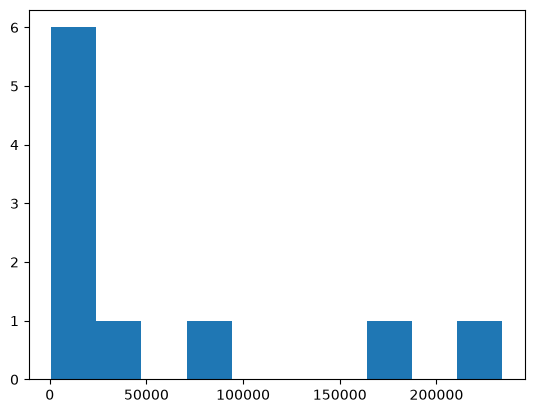

In [9]:
#Apply the right transform to every column you flagged in Q4, then recheck skew to confirm it dropped.
plt.hist(df['amount'],bins=10)
plt.show()

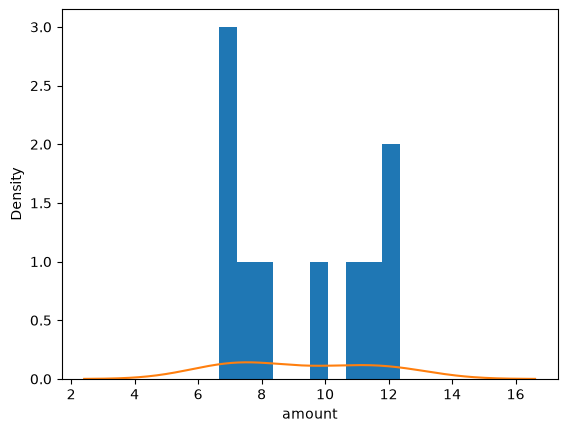

In [10]:
df['amount'] = np.log1p(df['amount'])
plt.hist(df['amount'],bins=10)
sns.kdeplot(data=df,x='amount')
plt.show()

In [ ]:
df['items_qty'] = np.log1p